In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

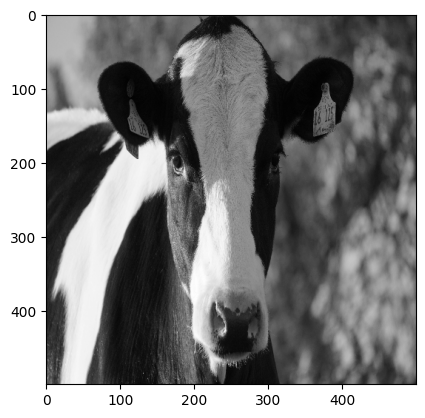

In [2]:
img = cv2.imread('pexels-gammel-23940471.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (500, 500))
plt.imshow(img, cmap='gray')


In [3]:
def corner_detector(image, window_size, k , threshold):
    copy = image.copy()
    height, width = image.shape
    blur = cv2.GaussianBlur(image, (3, 3), 0) # image, kernel size, sigma
    Ix = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3) # image, depth, x axis, y axis, kernel size
    Iy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3) # image, depth, x axis, y axis, kernel size
    Ixx = Ix ** 2
    Iyy = Iy ** 2
    Ixy = Ix * Iy
    offset = window_size // 2
    image_R_matrix = np.zeros((height, width))
    for y in range(offset, height - offset):
        for x in range(offset, width - offset):
            M_00 = np.sum(Ixx[y - offset : y + offset + 1, x - offset : x + offset + 1])
            M_11 = np.sum(Iyy[y - offset : y + offset + 1, x - offset : x + offset + 1])
            M_01 = np.sum(Ixy[y - offset : y + offset + 1, x - offset : x + offset + 1])
            M = np.array([[M_00, M_01], [M_01, M_11]])
            R = np.linalg.det(M) - k * (np.trace(M) ** 2)
            image_R_matrix[y, x] = R
    cv2.normalize(image_R_matrix, image_R_matrix, 0, 1, cv2.NORM_MINMAX) # Normalize the R values to the range [0, 1] (alpha, beta, norm_type)
    is_corners = image_R_matrix > threshold
    image_R_matrix[~is_corners] = 0
    image_R_matrix = cv2.dilate(image_R_matrix, None) # Dilate the R values to enhance corner points

    for y in range(offset, height - offset):
        for x in range(offset, width - offset):
            if image_R_matrix[y, x] != 0:
                cv2.circle(copy, (x, y), 5, (255, 0, 0), -1) # image, center, radius, color, thickness
    return copy

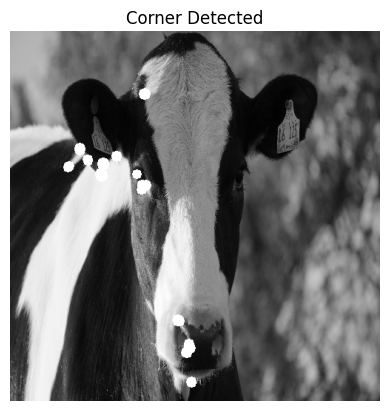

In [5]:
corner_img = corner_detector(img, window_size=5, k=0.04, threshold=0.24)
plt.imshow(corner_img, cmap='gray')
plt.title('Corner Detected')
plt.axis('off')
plt.show()

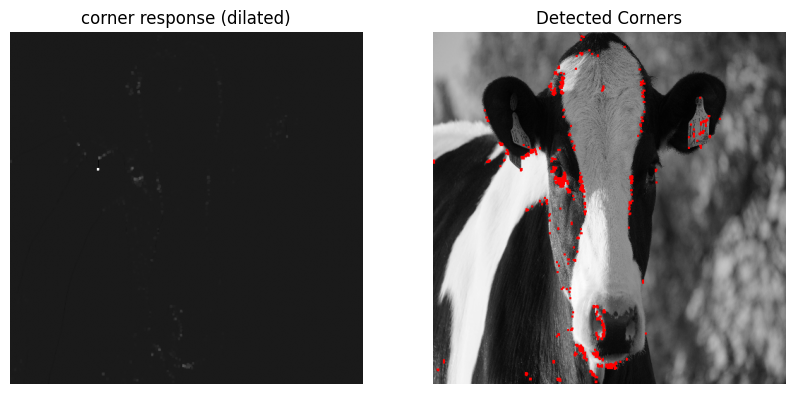

In [7]:
img_float = np.float32(img)
corner_img2 = cv2.cornerHarris(img_float, blockSize=2, ksize=3, k=0.04) # image, block size, kernel size, k
corner_img2 = cv2.dilate(corner_img2, None) # Dilate the corner response to enhance corner points

threshold = 0.01 * corner_img2.max() # Set the threshold for corner detection
corners_mask = corner_img2 > threshold
color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Convert grayscale image to RGB color image
color_img[corners_mask] = [0, 0, 255] # Mark corners in red
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(corner_img2, cmap='gray')
plt.title('corner response (dilated)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)) # Convert RGB color image back to BGR format for displaying with OpenCV
plt.title('Detected Corners')
plt.axis('off')
plt.show()
